In [1]:
# =========================
# CELL 1: SET DATA PATH
# =========================

phy_path = r"G:\Kevin\2026-02-26_14-01-37\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4"

print("Using data path:")
print(phy_path)

Using data path:
G:\Kevin\2026-02-26_14-01-37\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4


✅ channel_positions.npy loaded
Shape: (384, 2)

First 10 rows:
 [[ 0.  0.]
 [32.  0.]
 [ 0. 15.]
 [32. 15.]
 [ 0. 30.]
 [32. 30.]
 [ 0. 45.]
 [32. 45.]
 [ 0. 60.]
 [32. 60.]]

Unique X positions:
[ 0. 32.]

Differences between adjacent X:
[32.]

Assigned shank IDs (first 20 channels):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Unique shanks: [0]
Estimated number of shanks: 1


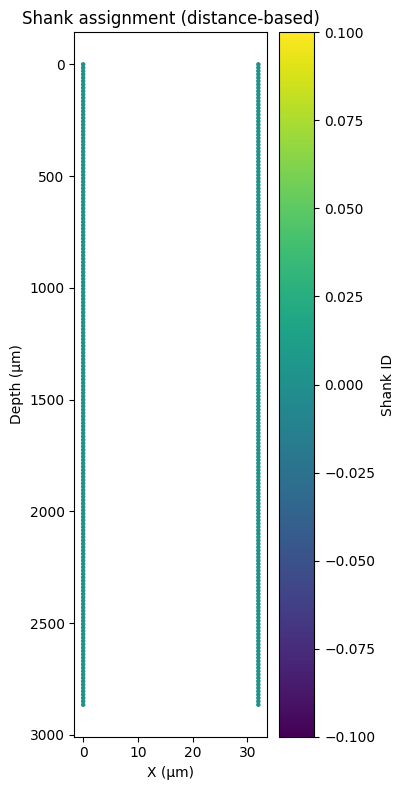

In [2]:
# =========================
# CELL 2: GEOMETRY CHECK + SHANK ASSIGNMENT
# =========================

import numpy as np
import os
import matplotlib.pyplot as plt

# ---- load channel positions ----
cp_path = os.path.join(phy_path, "channel_positions.npy")

if not os.path.exists(cp_path):
    print("❌ channel_positions.npy NOT found")
else:
    cp = np.load(cp_path)

    print("✅ channel_positions.npy loaded")
    print("Shape:", cp.shape)
    print("\nFirst 10 rows:\n", cp[:10])

    # ---- extract x coords ----
    x = cp[:, 0]
    ux = np.sort(np.unique(x))

    print("\nUnique X positions:")
    print(ux)

    print("\nDifferences between adjacent X:")
    print(np.diff(ux))

    # ---- threshold-based shank grouping ----
    threshold = 100  # microns

    shank_map = {}
    current_shank = 0
    shank_map[ux[0]] = current_shank

    for i in range(1, len(ux)):
        if ux[i] - ux[i-1] > threshold:
            current_shank += 1
        shank_map[ux[i]] = current_shank

    # ---- assign shank per channel ----
    shank_ids = np.array([shank_map[val] for val in x])

    print("\nAssigned shank IDs (first 20 channels):")
    print(shank_ids[:20])

    print("\nUnique shanks:", np.unique(shank_ids))
    print("Estimated number of shanks:", len(np.unique(shank_ids)))

    # ---- plot ----
    plt.figure(figsize=(4,8))
    plt.scatter(cp[:,0], cp[:,1], c=shank_ids, s=5)
    plt.gca().invert_yaxis()
    plt.title("Shank assignment (distance-based)")
    plt.xlabel("X (µm)")
    plt.ylabel("Depth (µm)")
    plt.colorbar(label="Shank ID")
    plt.tight_layout()
    plt.show()